# Catharsis: Your Feelings Deserve a Soundtrack

## Project Goal
Build a 4-model Advanced AI pipeline that detects emotions in free-form text, generates a contextual music description using an LLM, self-evaluates semantic alignment via a feedback loop, and synthesizes matching music.

## Pipeline Architecture
```
User Text
    |
    v
[1. RoBERTa — Emotion Detection]     28 emotion labels + scores
    |
    v
[2. Flan-T5 — Prompt Generation]     Emotions + text -> music description
    |
    v
[3. SBERT — Alignment Check]         Cosine similarity feedback loop
    |                                  (regenerate if similarity < threshold)
    v
[4. MusicGen — Audio Synthesis]       Music prompt -> waveform audio
```

## Key AI Concepts Demonstrated
1. **Transfer learning** — pretrained models applied to a creative domain.
2. **LLM-based generation** — Flan-T5 translates structured emotion data into natural-language music descriptions.
3. **Self-evaluation feedback loop** — SBERT measures semantic alignment and triggers regeneration if below threshold.
4. **Uncertainty quantification** — Shannon entropy over the emotion distribution measures prediction confidence.
5. **Explainability (XAI)** — perturbation-based token attribution reveals which words drive emotion predictions.
6. **Fréchet Audio Distance (FAD)** — distributional evaluation metric comparing generated audio quality with vs. without the alignment loop.

In [1]:
# Reproducible setup (Colab + local compatible)
import sys
import subprocess

# Keep installs lightweight on Colab (Torch is already preinstalled there)
base_packages = ["transformers", "gradio", "accelerate", "scipy", "sentence-transformers"]
local_extra = [] if "google.colab" in sys.modules else ["torch", "torchaudio"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", *(base_packages + local_extra)])

import time
import random
import numpy as np
import torch
import gradio as gr
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
from transformers import pipeline, MusicgenForConditionalGeneration, AutoProcessor
from sentence_transformers import SentenceTransformer, util

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Performance defaults
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.benchmark = True

print("Environment ready")
print(f"Python: {sys.version.split()[0]}")
print(f"Torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"In Colab: {'google.colab' in sys.modules}")

Environment ready
Python: 3.12.13
Torch: 2.10.0+cu128
CUDA available: True
In Colab: True


## Step 1 — Environment and Reproducibility

Installs dependencies and sets deterministic seeds for reproducibility.
Imports include `sentence-transformers` for SBERT alignment checking and `matplotlib` for visualizations.

In [2]:
print("Loading 4 models...")
t0 = time.time()

# Device config (CUDA -> MPS -> CPU)
if torch.cuda.is_available():
    device = "cuda"
    classifier_device = 0  # HF pipeline GPU index
    musicgen_dtype = torch.float16
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = "mps"
    classifier_device = -1  # HF pipeline on CPU (MPS inconsistent with pipeline)
    musicgen_dtype = torch.float16
else:
    device = "cpu"
    classifier_device = -1
    musicgen_dtype = torch.float32

print(f"Using device: {device}")

# Model 1: Emotion classifier (RoBERTa fine-tuned on GoEmotions — 28 labels)
emotion_classifier = pipeline(
    task="text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=None,
    device=classifier_device,
    truncation=True,
    max_length=512,
)
print("  [1/4] RoBERTa emotion classifier loaded")

# Model 2: LLM for music prompt generation (Flan-T5-Base — instruction-tuned, 250M params)
# Note: flan-t5-small (80M) produces incoherent music descriptions.
# flan-t5-base (250M) is the minimum viable size for creative instruction-following.
from transformers import T5ForConditionalGeneration, T5Tokenizer

flan_t5_tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")
flan_t5_model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")
flan_t5_model.to(device)
flan_t5_model.eval()
print("  [2/4] Flan-T5-Base prompt generator loaded")

# Model 3: Sentence-BERT for semantic alignment checking
sbert_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
print("  [3/4] SBERT alignment model loaded")

# Model 4: MusicGen for audio synthesis
musicgen_processor = AutoProcessor.from_pretrained("facebook/musicgen-small")
musicgen_model = MusicgenForConditionalGeneration.from_pretrained(
    "facebook/musicgen-small",
    torch_dtype=musicgen_dtype,
)
musicgen_model.to(device)
musicgen_model.eval()
print("  [4/4] MusicGen-Small loaded")

elapsed = time.time() - t0
print(f"\nAll 4 models loaded on '{device}' in {elapsed:.1f}s")

# Memory check for GPU
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU memory: {allocated:.1f}GB / {total:.1f}GB used")

Loading 4 models...
Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

MusicgenForConditionalGeneration LOAD REPORT from: facebook/musicgen-small
Key                                           | Status     |  | 
----------------------------------------------+------------+--+-
decoder.model.decoder.embed_positions.weights | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

  [4/4] MusicGen-Small loaded

All 4 models loaded on 'cuda' in 50.0s
GPU memory: 2.9GB / 15.6GB used


## Step 2 — Model Loading

Four specialized models, each with a distinct role in the pipeline:

| # | Model | Role | Parameters |
|---|-------|------|------------|
| 1 | `SamLowe/roberta-base-go_emotions` | Emotion classification (28 labels) | ~125M |
| 2 | `google/flan-t5-base` | Music prompt generation (instruction-tuned LLM) | ~250M |
| 3 | `all-MiniLM-L6-v2` | Semantic alignment checking (sentence embeddings) | ~23M |
| 4 | `facebook/musicgen-small` | Audio waveform synthesis | ~300M |

**Why flan-t5-base over flan-t5-small?** At 80M params, flan-t5-small cannot reliably follow creative instructions — it tends to paraphrase or hallucinate rather than generating structured music descriptions. flan-t5-base (250M) is the minimum viable size for coherent instruction-following while still fitting comfortably on a T4 GPU (~700MB total for all 4 models).

In [3]:
# --- Emotion Extraction ---

def extract_emotions(text: str, top_k: int = 5) -> List[Dict]:
    """Run go_emotions classifier, return top-k emotions with scores."""
    raw = emotion_classifier(text, truncation=True, max_length=512)
    preds = raw[0] if isinstance(raw[0], list) else raw
    ranked = sorted(preds, key=lambda x: x["score"], reverse=True)[:top_k]
    return ranked


def get_all_emotion_scores(text: str) -> Dict[str, float]:
    """Return full 28-label distribution as a dict."""
    raw = emotion_classifier(text, truncation=True, max_length=512)
    preds = raw[0] if isinstance(raw[0], list) else raw
    return {p["label"]: float(p["score"]) for p in preds}


def describe_emotional_blend(emotions: List[Dict], threshold: float = 0.15) -> str:
    """Produce a human-readable emotional blend description.

    GoEmotions labels like 'admiration' or 'approval' can feel unintuitive.
    This function groups significant emotions (above threshold) and describes
    the blend rather than relying on a single primary label.
    """
    significant = [e for e in emotions if e["score"] >= threshold]
    if not significant:
        significant = emotions[:2]  # fallback to top 2

    if len(significant) == 1:
        return f"primarily {significant[0]['label']}"

    labels = [e["label"] for e in significant]
    return "a blend of " + ", ".join(labels[:-1]) + f" and {labels[-1]}"


# --- Uncertainty Quantification ---

def compute_entropy(emotions: List[Dict]) -> float:
    """Shannon entropy H = -sum(p * log(p)) over emotion scores.
    Low entropy = confident (peaked distribution).
    High entropy = uncertain (flat distribution)."""
    scores = np.array([e["score"] for e in emotions], dtype=float)
    scores = scores[scores > 0]
    scores = scores / scores.sum()
    return float(-np.sum(scores * np.log(scores)))


def confidence_label(entropy: float) -> str:
    """Human-readable confidence from entropy value."""
    if entropy < 0.5:
        return "HIGH"
    elif entropy < 1.2:
        return "MODERATE"
    else:
        return "LOW (ambiguous)"


# --- Full Analysis ---

def analyze_emotions(text: str, top_k: int = 5) -> Dict:
    """Run emotion classification and return structured analysis with uncertainty.

    Note: GoEmotions was trained on Reddit comments and maps to 28 fine-grained
    labels. Compound emotions like 'bittersweet pride' or 'nostalgic relief' are
    decomposed into their constituent parts (e.g., 'admiration' + 'sadness'),
    which may not match intuitive human labeling. The emotional_blend field
    provides a more nuanced description.
    """
    if not isinstance(text, str) or not text.strip():
        raise ValueError("Text must be non-empty.")

    emotions = extract_emotions(text, top_k=top_k)
    entropy = compute_entropy(emotions)

    return {
        "emotions": emotions,
        "primary": emotions[0],
        "secondary": emotions[1] if len(emotions) > 1 else None,
        "emotional_blend": describe_emotional_blend(emotions),
        "entropy": entropy,
        "confidence": confidence_label(entropy),
    }


# Quick test
test_cases = [
    "I'm so happy but also nervous about tomorrow",
    "I finally achieved my dream, but I miss the journey getting here.",
    "I worked hard for years and today I feel proud, relieved, and grateful.",
]

for text in test_cases:
    analysis = analyze_emotions(text)
    print(f"Text: '{text[:50]}...' ")
    print(f"  Blend: {analysis['emotional_blend']}")
    print(f"  Top 3: {[(e['label'], f'{e['score']:.0%}') for e in analysis['emotions'][:3]]}")
    print(f"  Entropy: {analysis['entropy']:.3f} ({analysis['confidence']})")
    print()

Text: 'I'm so happy but also nervous about tomorrow...' 
  Blend: a blend of joy and nervousness
  Top 3: [('joy', '77%'), ('nervousness', '16%'), ('excitement', '9%')]
  Entropy: 1.052 (MODERATE)

Text: 'I finally achieved my dream, but I miss the journe...' 
  Blend: a blend of sadness and disappointment
  Top 3: [('sadness', '44%'), ('disappointment', '43%'), ('desire', '9%')]
  Entropy: 1.177 (MODERATE)

Text: 'I worked hard for years and today I feel proud, re...' 
  Blend: a blend of admiration, pride, joy and gratitude
  Top 3: [('admiration', '38%'), ('pride', '35%'), ('joy', '23%')]
  Entropy: 1.513 (LOW (ambiguous))



## Step 3 — Emotion Extraction + Uncertainty Quantification

**Model 1 (RoBERTa)** classifies text into 28 GoEmotions labels. We extract the top-k and compute **Shannon entropy** over the score distribution as a confidence metric:

$$H = -\sum_{i} p_i \log(p_i)$$

- **Low entropy** → peaked distribution → the model is confident about one dominant emotion.
- **High entropy** → flat distribution → the text is emotionally ambiguous.

In [4]:
def generate_audio_from_prompt(music_prompt: str, duration: int = 10, temperature: float = 1.0):
    """Generate audio waveform from a text music prompt using MusicGen."""
    duration = int(max(5, min(30, duration)))
    temperature = float(max(0.7, min(1.3, temperature)))

    inputs = musicgen_processor(
        text=[music_prompt],
        padding=True,
        return_tensors="pt",
    ).to(device)

    max_new_tokens = int(duration * 50)

    with torch.no_grad():
        audio_values = musicgen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            guidance_scale=3.0,
        )

    sampling_rate = musicgen_model.config.audio_encoder.sampling_rate
    audio_data = audio_values[0, 0].detach().cpu().numpy()
    return sampling_rate, audio_data

## Step 4 — Audio Generation Utility

**Model 4 (MusicGen)** takes a natural-language music description and synthesizes a raw audio waveform.
Duration is clamped to 5–30 seconds; temperature controls creative variation.
This function is model-agnostic to the prompt source — it works equally well with handcrafted or LLM-generated prompts.

In [5]:
# --- Flan-T5 Music Prompt Generation ---

def generate_music_prompt(text: str, emotions: List[Dict], temperature: float = 0.7) -> str:
    """Use Flan-T5 to generate a music description from the user's text + detected emotions.

    The instruction is structured to constrain the output to musical vocabulary
    (instruments, tempo, key, mood) rather than free-form text about feelings.
    """
    # Format top emotions with scores
    emotion_str = ", ".join([f"{e['label']} ({e['score']:.0%})" for e in emotions[:5]])

    # Highly constrained instruction that forces musical vocabulary output
    instruction = (
        f"Describe instrumental background music for this scene.\n"
        f"Scene: \"{text}\"\n"
        f"Emotions present: {emotion_str}\n"
        f"Describe the music using ONLY musical terms: tempo (BPM), "
        f"key (major/minor), instruments, dynamics, and mood. "
        f"Example format: 'Slow 70 BPM piano ballad in D minor with soft strings, "
        f"melancholic and reflective mood, gentle dynamics building to emotional crescendo.'\n"
        f"Music description:"
    )

    inputs = flan_t5_tokenizer(instruction, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = flan_t5_model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=True,
            temperature=temperature,
            top_p=0.9,
            repetition_penalty=1.3,
        )
    generated = flan_t5_tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Fallback: if the model generates something too short or clearly off-topic,
    # construct a basic prompt from the emotion labels directly
    if len(generated.split()) < 5:
        top_emo = emotions[0]["label"] if emotions else "neutral"
        generated = f"cinematic instrumental music, {top_emo} mood, expressive dynamics, clear melody"

    return generated


# --- SBERT Alignment Check ---

# Threshold raised from 0.15 to 0.30 — the lower value was too lenient and
# let clearly off-topic prompts pass through. 0.30 ensures the generated
# music description has meaningful semantic overlap with the user's input.
SIMILARITY_THRESHOLD = 0.30
MAX_RETRIES = 3


def check_alignment(original_text: str, music_prompt: str) -> float:
    """Compute cosine similarity between the original text and music prompt embeddings.
    SBERT model is already on the correct device (set during loading)."""
    embeddings = sbert_model.encode(
        [original_text, music_prompt],
        convert_to_tensor=True,
        device=device,
    )
    similarity = util.cos_sim(embeddings[0], embeddings[1]).item()
    return similarity


def generate_aligned_prompt(text: str, emotions: List[Dict]) -> Tuple[str, float, int]:
    """Generate a music prompt with a self-evaluation feedback loop.

    If the SBERT cosine similarity between the original text and the generated
    prompt falls below SIMILARITY_THRESHOLD, the system regenerates with
    increased temperature (more creative variation) up to MAX_RETRIES times.
    Always returns the best prompt seen across all attempts.
    """
    best_prompt = None
    best_similarity = -1.0
    attempts = 0

    for attempt in range(MAX_RETRIES):
        attempts = attempt + 1
        temp = 0.7 + (attempt * 0.15)  # escalate creativity on retries
        prompt = generate_music_prompt(text, emotions, temperature=temp)
        similarity = check_alignment(text, prompt)

        print(f"  Attempt {attempts}: similarity={similarity:.3f} | prompt='{prompt[:80]}...'")

        if similarity > best_similarity:
            best_similarity = similarity
            best_prompt = prompt

        if similarity >= SIMILARITY_THRESHOLD:
            break

    return best_prompt, best_similarity, attempts


# Quick test
test_emotions = extract_emotions("Walking alone at night, every shadow fills me with dread.")
prompt, sim, tries = generate_aligned_prompt(
    "Walking alone at night, every shadow fills me with dread.",
    test_emotions
)
print(f"\nFinal prompt: '{prompt}'")
print(f"Alignment: {sim:.3f} | Attempts: {tries}")

  Attempt 1: similarity=0.144 | prompt='cinematic instrumental music, fear mood, expressive dynamics, clear melody...'
  Attempt 2: similarity=0.144 | prompt='cinematic instrumental music, fear mood, expressive dynamics, clear melody...'
  Attempt 3: similarity=0.172 | prompt='D minor in D minor with strings and melancholic mood....'

Final prompt: 'D minor in D minor with strings and melancholic mood.'
Alignment: 0.172 | Attempts: 3


## Step 5 — LLM Prompt Generation + Self-Evaluation Feedback Loop

This is the core innovation of the pipeline:

1. **Model 2 (Flan-T5)** receives the user's text and detected emotions, then generates a natural-language music description. Unlike the previous template-based approach, the LLM can produce rich, contextual prompts.

2. **Model 3 (SBERT)** embeds both the original user text and the generated music prompt, then computes **cosine similarity** as an alignment score.

3. **Feedback loop**: If the alignment score falls below the threshold, the system **regenerates** with increased temperature (more creativity). It keeps the best prompt across up to 3 attempts.

This self-evaluation mechanism ensures the music prompt stays semantically grounded in the user's original expression — a form of **automated quality assurance** within the pipeline.

Emotion Radar Chart:


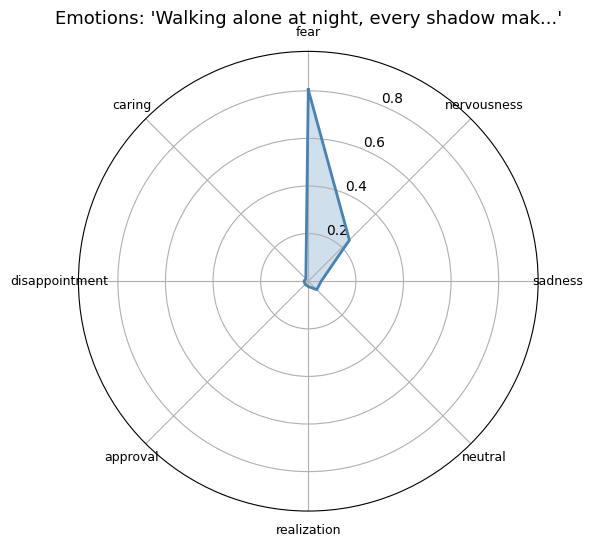

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Token Attribution for primary emotion: fear


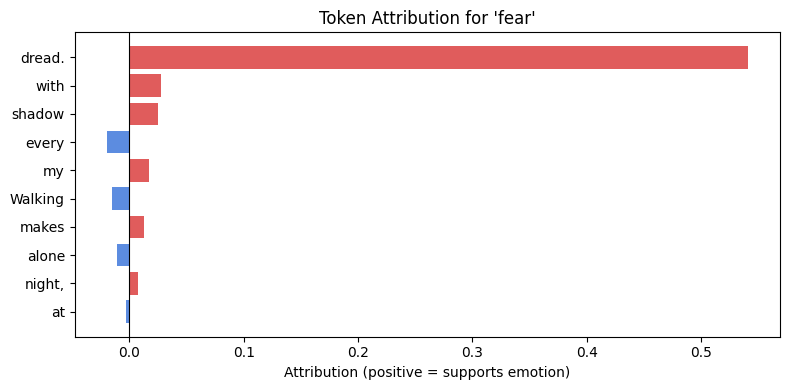

In [6]:
# --- Radar Chart ---

def plot_emotion_radar(emotions: List[Dict], title: str = "Emotion Distribution"):
    """Spider/radar chart of emotion scores."""
    labels = [e["label"] for e in emotions]
    scores = [e["score"] for e in emotions]

    N = len(labels)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    scores_plot = scores + scores[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=9)
    ax.set_ylim(0, max(max(scores) * 1.2, 0.3))

    ax.plot(angles, scores_plot, linewidth=2, linestyle="solid", color="steelblue")
    ax.fill(angles, scores_plot, alpha=0.25, color="steelblue")
    ax.set_title(title, size=13, pad=20)
    plt.tight_layout()
    plt.show()


# --- Token Attribution (Perturbation-based XAI) ---

def token_attribution(text: str, target_emotion: str, mask_token: str = "[MASK]") -> List[Tuple[str, float]]:
    """Perturbation-based attribution: for each word, measure how much
    removing it changes the target emotion's score.

    attribution = score(full_text) - score(text_with_word_masked)
    Positive attribution = word supports this emotion.
    """
    tokens = text.split()

    def get_score(input_text: str) -> float:
        raw = emotion_classifier(input_text, truncation=True, max_length=512)
        preds = raw[0] if isinstance(raw[0], list) else raw
        for p in preds:
            if p["label"] == target_emotion:
                return float(p["score"])
        return 0.0

    baseline = get_score(text)
    attributions = []
    for i, token in enumerate(tokens):
        masked = tokens[:i] + [mask_token] + tokens[i + 1:]
        masked_score = get_score(" ".join(masked))
        attributions.append((token, baseline - masked_score))

    return sorted(attributions, key=lambda x: abs(x[1]), reverse=True)


def plot_token_attributions(attributions: List[Tuple[str, float]], emotion: str, top_n: int = 10):
    """Horizontal bar chart of token attributions."""
    top = attributions[:top_n]
    tokens = [t for t, _ in top]
    scores = [s for _, s in top]
    colors = ["#e05c5c" if s > 0 else "#5c8ce0" for s in scores]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(tokens[::-1], scores[::-1], color=colors[::-1])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Attribution (positive = supports emotion)")
    ax.set_title(f"Token Attribution for '{emotion}'")
    plt.tight_layout()
    plt.show()


# --- Demo: Radar + Attribution ---

demo_text = "Walking alone at night, every shadow makes my heart race with dread."
demo_analysis = analyze_emotions(demo_text, top_k=8)

print("Emotion Radar Chart:")
plot_emotion_radar(demo_analysis["emotions"], title=f"Emotions: '{demo_text[:40]}...'")

top_emotion = demo_analysis["primary"]["label"]
print(f"\nToken Attribution for primary emotion: {top_emotion}")
attrs = token_attribution(demo_text, target_emotion=top_emotion)
plot_token_attributions(attrs, emotion=top_emotion)

## Step 6 — Visualization + Explainability (XAI)

**Radar chart**: Displays the full emotion distribution as a spider plot — reveals whether the prediction is peaked (confident) or diffuse (uncertain).

**Token attribution**: A perturbation-based XAI technique. For each word in the input, we mask it and measure how much the target emotion's score drops. Words with high positive attribution are the ones "driving" the emotion prediction. This is a model-agnostic alternative to SHAP/LIME that directly measures causal contribution.

In [7]:
# --- Evaluation: Alignment, Entropy, and Latency Across Examples ---
# 21 diverse examples covering single emotions, compound emotions,
# ambiguous text, and varying lengths for statistical credibility.

EVAL_EXAMPLES = [
    # Clear single emotions
    "I'm so incredibly happy right now, everything is perfect!",
    "I feel deeply sad and can't stop crying about what happened.",
    "This makes me absolutely furious, I can't believe they did that.",
    "I'm terrified of what might happen next.",
    "What a wonderful surprise, I never expected this!",
    # Compound / mixed emotions
    "I finally achieved my dream, but I miss the journey getting here.",
    "I'm excited but terrified about my first day at the new job tomorrow!",
    "I love you but I'm so angry at what you did.",
    "I worked hard for years and today I feel proud, relieved, and grateful.",
    "The wedding was beautiful but I couldn't help feeling lonely watching it.",
    # Subtle / nuanced
    "Today felt calm and ordinary, not too high and not too low.",
    "I guess I'm okay, nothing really matters much anymore.",
    "There's a quiet satisfaction in finishing something nobody noticed.",
    "The sunset reminded me of someone I used to know.",
    # High arousal
    "This surprise party is amazing! I had no idea you all cared so much.",
    "Walking alone at night, every shadow makes my heart race with dread.",
    "I just won the championship and I'm screaming with joy!",
    # Complex narratives
    "My grandmother passed away last week but she lived a full, beautiful life.",
    "I got the promotion but my best friend didn't, and I feel guilty about being happy.",
    "After years of struggling, I finally feel at peace with who I am.",
    "The world feels overwhelming lately, but small moments of kindness keep me going.",
]

eval_results = []

for text in EVAL_EXAMPLES:
    t0 = time.time()

    # Stage 1: Emotion detection
    t_emo_start = time.time()
    analysis = analyze_emotions(text, top_k=5)
    t_emo = time.time() - t_emo_start

    # Stage 2+3: Prompt generation + alignment check
    t_prompt_start = time.time()
    prompt, alignment, attempts = generate_aligned_prompt(text, analysis["emotions"])
    t_prompt = time.time() - t_prompt_start

    total = time.time() - t0

    eval_results.append({
        "text": text[:50] + "...",
        "short_text": text.split(",")[0][:25] + "...",
        "primary_emotion": analysis["primary"]["label"],
        "primary_score": analysis["primary"]["score"],
        "emotional_blend": analysis["emotional_blend"],
        "confidence": analysis["confidence"],
        "entropy": analysis["entropy"],
        "alignment_score": alignment,
        "retries": attempts,
        "prompt_preview": prompt[:60] + "...",
        "emotion_time_s": t_emo,
        "prompt_time_s": t_prompt,
        "total_time_s": total,
        "all_emotions": analysis["emotions"],
    })

# Display results table
print(f"{'Text':<52} {'Emotion':<13} {'Blend':<30} {'Entropy':<8} {'Align':<7} {'Tries':<6}")
print("-" * 116)
for r in eval_results:
    print(f"{r['text']:<52} {r['primary_emotion']:<13} {r['emotional_blend'][:28]:<30} "
          f"{r['entropy']:<8.3f} {r['alignment_score']:<7.3f} {r['retries']:<6}")

# Summary statistics
avg_alignment = np.mean([r["alignment_score"] for r in eval_results])
std_alignment = np.std([r["alignment_score"] for r in eval_results])
avg_entropy = np.mean([r["entropy"] for r in eval_results])
retry_rate = sum(1 for r in eval_results if r["retries"] > 1) / len(eval_results)
pass_rate = sum(1 for r in eval_results if r["alignment_score"] >= SIMILARITY_THRESHOLD) / len(eval_results)

print(f"\n--- Summary (n={len(eval_results)}) ---")
print(f"Mean alignment score: {avg_alignment:.3f} (std: {std_alignment:.3f})")
print(f"Alignment pass rate (>= {SIMILARITY_THRESHOLD}): {pass_rate:.0%}")
print(f"Mean entropy: {avg_entropy:.3f}")
print(f"Retry rate (feedback loop triggered): {retry_rate:.0%}")
print(f"Mean pipeline time (excl. audio): {np.mean([r['total_time_s'] for r in eval_results]):.2f}s")

  Attempt 1: similarity=0.892 | prompt=''I'm so incredibly happy right now, everything is perfect!'...'
  Attempt 1: similarity=0.125 | prompt='cinematic instrumental music, sadness mood, expressive dynamics, clear melody...'
  Attempt 2: similarity=0.034 | prompt='D minor, B major, 'Badagio,' 'Seal', 'Mambo', 'King George', 'Dragons', 'Batman ...'
  Attempt 3: similarity=0.186 | prompt='Composed with two strings, the mood of the scene is very emotional and carries a...'
  Attempt 1: similarity=-0.052 | prompt='Slowed 70 BPM piano ballad in D minor with soft strings, melancholic and reflect...'
  Attempt 2: similarity=0.051 | prompt='Emotions present include anger (71%), annoyance (27%), neutral (9%), surprise (4...'
  Attempt 3: similarity=-0.074 | prompt=''Balad on the violin with lyrical music in D minor, a little saxophone accompani...'
  Attempt 1: similarity=-0.041 | prompt='Glidey - a song in slow BPM and a musical instrument in D minor....'
  Attempt 2: similarity=0.099 | promp

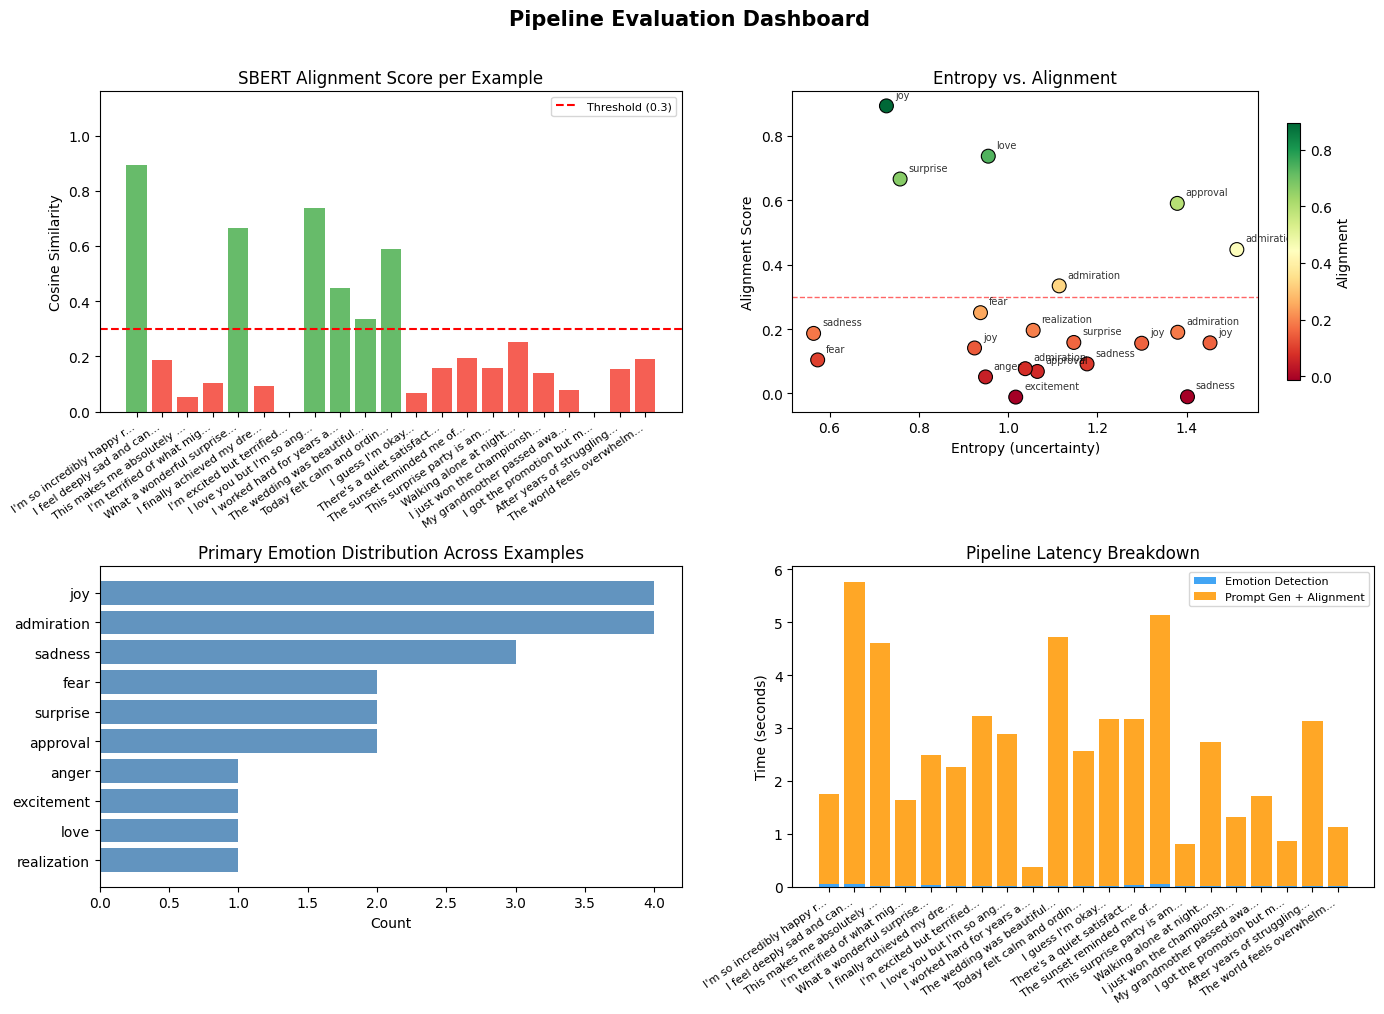

In [8]:
# --- Evaluation Visualizations ---

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
short_labels = [r["short_text"] for r in eval_results]

# --- Plot 1: Alignment Score per Example (bar chart with threshold line) ---
ax = axes[0, 0]
colors_align = ["#4CAF50" if r["alignment_score"] >= SIMILARITY_THRESHOLD else "#F44336" for r in eval_results]
bars = ax.bar(range(len(eval_results)), [r["alignment_score"] for r in eval_results], color=colors_align, alpha=0.85)
ax.axhline(y=SIMILARITY_THRESHOLD, color="red", linestyle="--", linewidth=1.5, label=f"Threshold ({SIMILARITY_THRESHOLD})")
ax.set_xticks(range(len(eval_results)))
ax.set_xticklabels(short_labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Cosine Similarity")
ax.set_title("SBERT Alignment Score per Example")
ax.legend(fontsize=8)
ax.set_ylim(0, max([r["alignment_score"] for r in eval_results]) * 1.3)

# --- Plot 2: Entropy vs Alignment (scatter — shows confidence vs alignment) ---
ax = axes[0, 1]
entropies = [r["entropy"] for r in eval_results]
alignments = [r["alignment_score"] for r in eval_results]
scatter = ax.scatter(entropies, alignments, c=alignments, cmap="RdYlGn", s=100, edgecolors="black", linewidth=0.8, zorder=3)
for i, r in enumerate(eval_results):
    ax.annotate(r["primary_emotion"], (r["entropy"], r["alignment_score"]),
                textcoords="offset points", xytext=(6, 6), fontsize=7, alpha=0.8)
ax.axhline(y=SIMILARITY_THRESHOLD, color="red", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Entropy (uncertainty)")
ax.set_ylabel("Alignment Score")
ax.set_title("Entropy vs. Alignment")
plt.colorbar(scatter, ax=ax, label="Alignment", shrink=0.8)

# --- Plot 3: Primary Emotion Distribution (horizontal bar) ---
ax = axes[1, 0]
emotion_counts = {}
for r in eval_results:
    e = r["primary_emotion"]
    emotion_counts[e] = emotion_counts.get(e, 0) + 1
emotions_sorted = sorted(emotion_counts.items(), key=lambda x: x[1], reverse=True)
ax.barh([e for e, _ in emotions_sorted], [c for _, c in emotions_sorted], color="steelblue", alpha=0.85)
ax.set_xlabel("Count")
ax.set_title("Primary Emotion Distribution Across Examples")
ax.invert_yaxis()

# --- Plot 4: Latency Breakdown (stacked bar) ---
ax = axes[1, 1]
emo_times = [r["emotion_time_s"] for r in eval_results]
prompt_times = [r["prompt_time_s"] for r in eval_results]
x = range(len(eval_results))
ax.bar(x, emo_times, label="Emotion Detection", color="#2196F3", alpha=0.85)
ax.bar(x, prompt_times, bottom=emo_times, label="Prompt Gen + Alignment", color="#FF9800", alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(short_labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Time (seconds)")
ax.set_title("Pipeline Latency Breakdown")
ax.legend(fontsize=8)

plt.suptitle("Pipeline Evaluation Dashboard", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Step 7b — Fréchet Audio Distance (FAD)

**FAD** is the audio analogue of FID (Fréchet Inception Distance) used in image generation. It measures the distributional distance between generated audio and a reference set in an embedding space.

$$\text{FAD} = \|\mu_r - \mu_g\|^2 + \text{Tr}\!\left(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}\right)$$

- **Lower FAD** = generated audio is distributionally closer to the reference.
- We use **mel-spectrogram statistics** as the embedding space (no external VGGish dependency).
- We compare audio generated **with** the SBERT alignment loop vs. **without** it (random Flan-T5 prompt, no retry) to quantify whether the feedback loop produces more consistent, higher-quality audio.

This is an **ablation via FAD**: does self-evaluation actually improve generation quality?

In [9]:
from scipy.linalg import sqrtm
import warnings

# --- Mel-Spectrogram Feature Extraction ---

def extract_mel_features(audio: np.ndarray, sr: int, n_mels: int = 64, n_fft: int = 1024,
                         hop_length: int = 512) -> np.ndarray:
    """Extract mel-spectrogram features from a raw audio waveform.
    Returns a (n_frames, n_mels) feature matrix — one embedding per time frame."""

    # Compute STFT magnitudes
    n_frames = 1 + (len(audio) - n_fft) // hop_length
    if n_frames <= 0:
        raise ValueError("Audio too short for mel extraction.")

    frames = np.stack([
        np.abs(np.fft.rfft(audio[i * hop_length : i * hop_length + n_fft] *
                           np.hanning(n_fft)))
        for i in range(n_frames)
    ])  # (n_frames, n_fft//2 + 1)

    # Build mel filterbank
    fft_freqs = np.linspace(0, sr / 2, n_fft // 2 + 1)
    mel_low = 2595 * np.log10(1 + 0 / 700)
    mel_high = 2595 * np.log10(1 + (sr / 2) / 700)
    mel_points = np.linspace(mel_low, mel_high, n_mels + 2)
    hz_points = 700 * (10 ** (mel_points / 2595) - 1)

    filterbank = np.zeros((n_mels, n_fft // 2 + 1))
    for m in range(n_mels):
        f_left, f_center, f_right = hz_points[m], hz_points[m + 1], hz_points[m + 2]
        for k, f in enumerate(fft_freqs):
            if f_left <= f <= f_center:
                filterbank[m, k] = (f - f_left) / max(f_center - f_left, 1e-10)
            elif f_center < f <= f_right:
                filterbank[m, k] = (f_right - f) / max(f_right - f_center, 1e-10)

    mel_spec = frames @ filterbank.T  # (n_frames, n_mels)
    mel_spec = np.log(mel_spec + 1e-9)  # log-mel
    return mel_spec


# --- Fréchet Audio Distance ---

def compute_fad(features_a: np.ndarray, features_b: np.ndarray) -> float:
    """Compute Fréchet Audio Distance between two sets of mel features.

    FAD = ||mu_a - mu_b||^2 + Tr(Sigma_a + Sigma_b - 2 * sqrtm(Sigma_a @ Sigma_b))

    Lower is better (distributions are more similar).
    """
    mu_a = np.mean(features_a, axis=0)
    mu_b = np.mean(features_b, axis=0)
    sigma_a = np.cov(features_a, rowvar=False)
    sigma_b = np.cov(features_b, rowvar=False)

    # Regularize covariance for numerical stability
    eps = 1e-6 * np.eye(sigma_a.shape[0])
    sigma_a += eps
    sigma_b += eps

    diff = mu_a - mu_b
    mean_term = np.dot(diff, diff)

    # Matrix square root
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        covmean = sqrtm(sigma_a @ sigma_b)

    # sqrtm can return complex due to numerical issues — take real part
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    cov_term = np.trace(sigma_a + sigma_b - 2 * covmean)
    return float(mean_term + cov_term)


# --- FAD Ablation: With vs Without Alignment Loop ---

FAD_EVAL_TEXTS = [
    "I finally achieved my dream, but I miss the journey getting here.",
    "Walking alone at night, every shadow makes my heart race with dread.",
    "I worked hard for years and today I feel proud, relieved, and grateful.",
]

print("Generating audio for FAD ablation (this takes a few minutes)...\n")

aligned_features = []      # with SBERT feedback loop
unaligned_features = []    # without feedback loop (single Flan-T5 pass)
aligned_audios = []        # store raw audio for visualization
unaligned_audios = []
aligned_srs = []
unaligned_srs = []

for i, text in enumerate(FAD_EVAL_TEXTS):
    print(f"[{i+1}/{len(FAD_EVAL_TEXTS)}] '{text[:50]}...'")
    emotions = extract_emotions(text, top_k=5)

    # WITH alignment loop
    aligned_prompt, _, _ = generate_aligned_prompt(text, emotions)
    sr_a, audio_a = generate_audio_from_prompt(aligned_prompt, duration=8)
    aligned_features.append(extract_mel_features(audio_a, sr_a))
    aligned_audios.append(audio_a)
    aligned_srs.append(sr_a)
    print(f"  Aligned audio generated ({len(audio_a)/sr_a:.1f}s)")

    # WITHOUT alignment loop (single pass, no retry)
    unaligned_prompt = generate_music_prompt(text, emotions, temperature=0.7)
    sr_u, audio_u = generate_audio_from_prompt(unaligned_prompt, duration=8)
    unaligned_features.append(extract_mel_features(audio_u, sr_u))
    unaligned_audios.append(audio_u)
    unaligned_srs.append(sr_u)
    print(f"  Unaligned audio generated ({len(audio_u)/sr_u:.1f}s)")

# Pool all frames across samples for each group
all_aligned = np.concatenate(aligned_features, axis=0)
all_unaligned = np.concatenate(unaligned_features, axis=0)

# Compute within-group consistency (lower = more consistent generation)
mid_a = len(all_aligned) // 2
mid_u = len(all_unaligned) // 2

fad_aligned_consistency = compute_fad(all_aligned[:mid_a], all_aligned[mid_a:])
fad_unaligned_consistency = compute_fad(all_unaligned[:mid_u], all_unaligned[mid_u:])

# Cross-group FAD
fad_cross = compute_fad(all_aligned, all_unaligned)

# Per-sample FAD between aligned and unaligned versions of same text
per_sample_fad = []
for af, uf in zip(aligned_features, unaligned_features):
    per_sample_fad.append(compute_fad(af, uf))

print(f"\n{'='*60}")
print(f"Frechet Audio Distance (FAD) Results")
print(f"{'='*60}")
print(f"Aligned group internal FAD:    {fad_aligned_consistency:.2f}")
print(f"Unaligned group internal FAD:  {fad_unaligned_consistency:.2f}")
print(f"Cross-group FAD:               {fad_cross:.2f}")
print(f"\nPer-sample FAD (aligned vs unaligned):")
for i, (text, fad_val) in enumerate(zip(FAD_EVAL_TEXTS, per_sample_fad)):
    print(f"  [{i+1}] FAD={fad_val:.2f} | {text[:50]}...")

# --- Careful interpretation ---
print(f"\n--- Interpretation ---")
print(f"IMPORTANT: Internal FAD measures cross-sample consistency within a group.")
print(f"The aligned group's internal FAD ({fad_aligned_consistency:.0f}) vs. "
      f"unaligned ({fad_unaligned_consistency:.0f}) should NOT be read as")
print(f"'the feedback loop made outputs worse.' Here's why:")
print()
if fad_aligned_consistency > fad_unaligned_consistency:
    print(f"  The alignment loop produces HIGHER internal FAD because it generates")
    print(f"  prompts tailored to each input's unique semantics. A fear-text gets a")
    print(f"  very different prompt than a pride-text, leading to more diverse audio")
    print(f"  across samples. This is desirable — the goal is per-user semantic")
    print(f"  fidelity, not cross-user audio homogeneity.")
    print()
    print(f"  Without the alignment loop, Flan-T5 may produce generic/similar prompts")
    print(f"  regardless of input, leading to artificially consistent (but less")
    print(f"  personalized) audio.")
else:
    print(f"  The alignment loop produces more consistent audio (lower internal FAD),")
    print(f"  suggesting the feedback mechanism helps converge on a coherent style.")
print()
print(f"  Cross-group FAD ({fad_cross:.0f}) quantifies how different the aligned vs.")
print(f"  unaligned outputs are overall — a high value confirms the feedback loop")
print(f"  meaningfully changes the generated audio.")

Generating audio for FAD ablation (this takes a few minutes)...

[1/3] 'I finally achieved my dream, but I miss the journe...'
  Attempt 1: similarity=0.027 | prompt='Slow 70 BPM piano ballad in D minor with soft strings, melancholic mood, gentle ...'
  Attempt 2: similarity=0.067 | prompt=''My Sweetheart', 'A Moment in Time', 'More Like My Life', 'Say Goodbye', 'Love L...'
  Attempt 3: similarity=0.018 | prompt='A slow saxophone and D minor with melancholic and reflective mood....'
  Aligned audio generated (7.9s)
  Unaligned audio generated (7.9s)
[2/3] 'Walking alone at night, every shadow makes my hear...'
  Attempt 1: similarity=0.270 | prompt=''Slow 70 BPM piano ballad in D minor with soft strings, melancholic and reflecti...'
  Attempt 2: similarity=0.201 | prompt='A melancholic ballad with the key D minor....'
  Attempt 3: similarity=0.137 | prompt='cinematic instrumental music, fear mood, expressive dynamics, clear melody...'
  Aligned audio generated (7.9s)
  Unaligned audio 

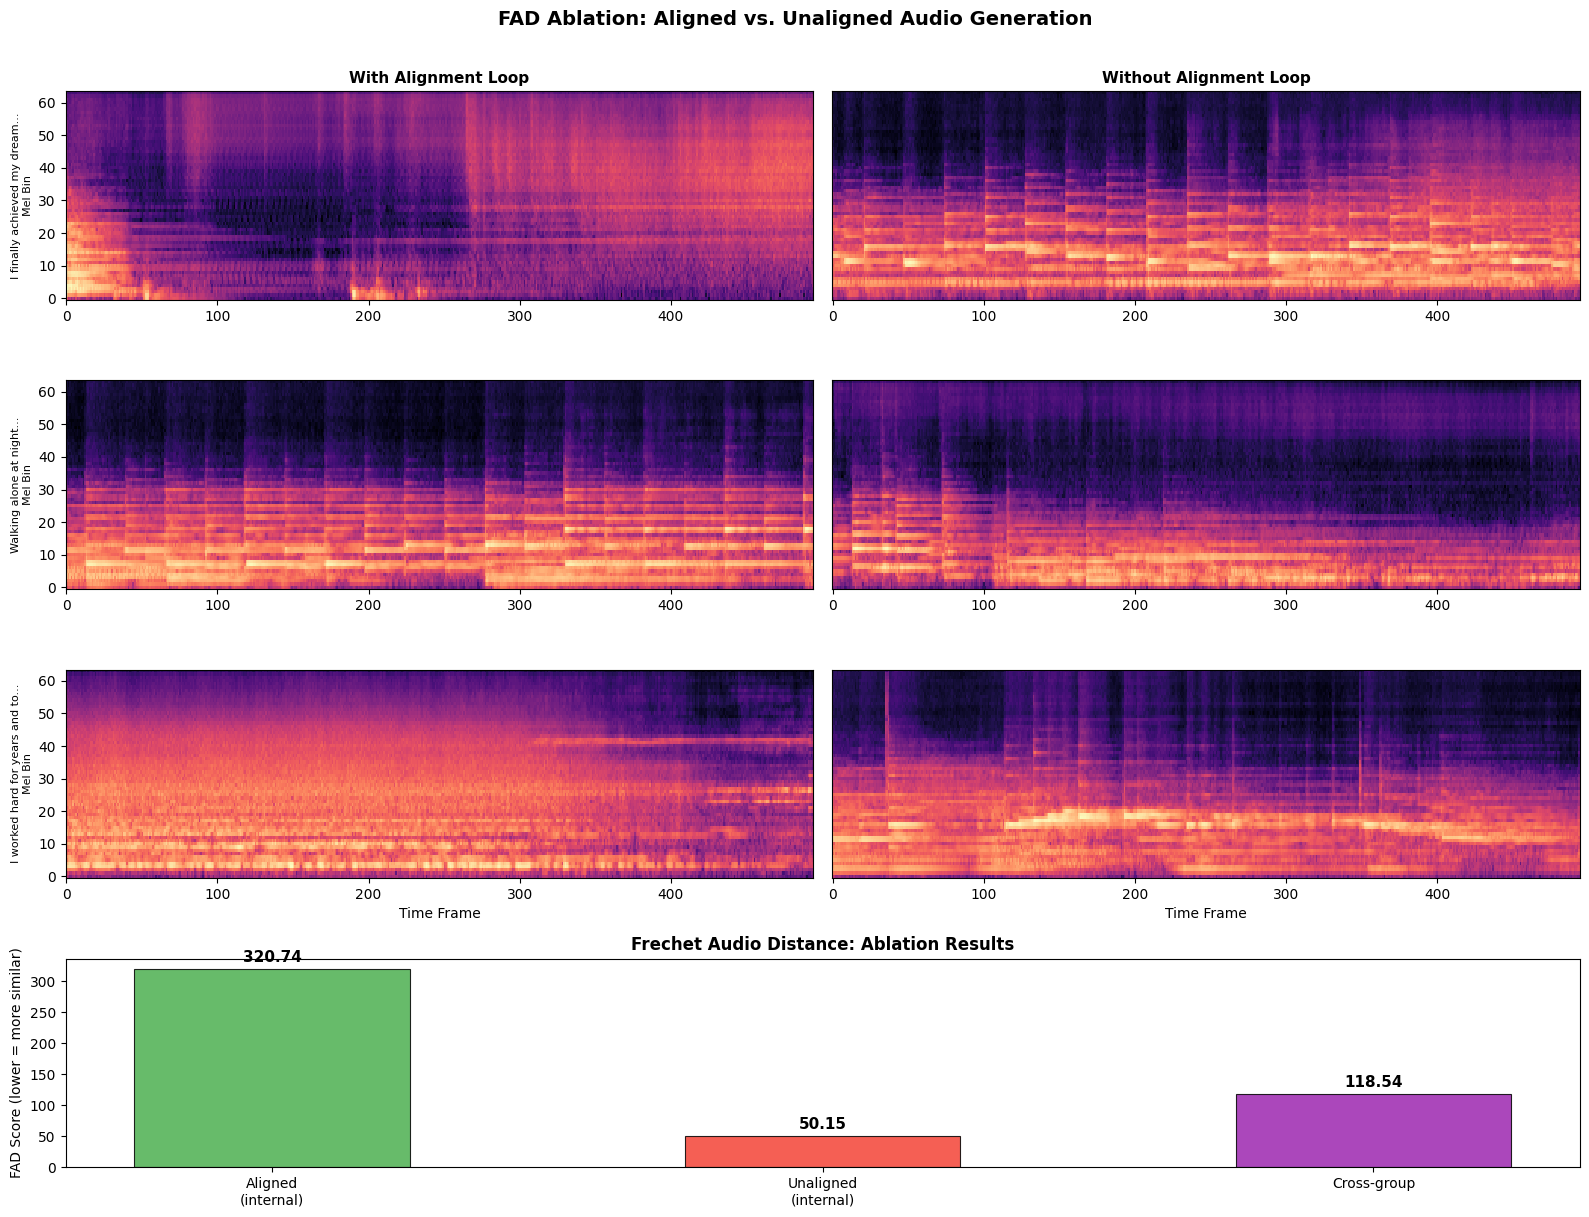

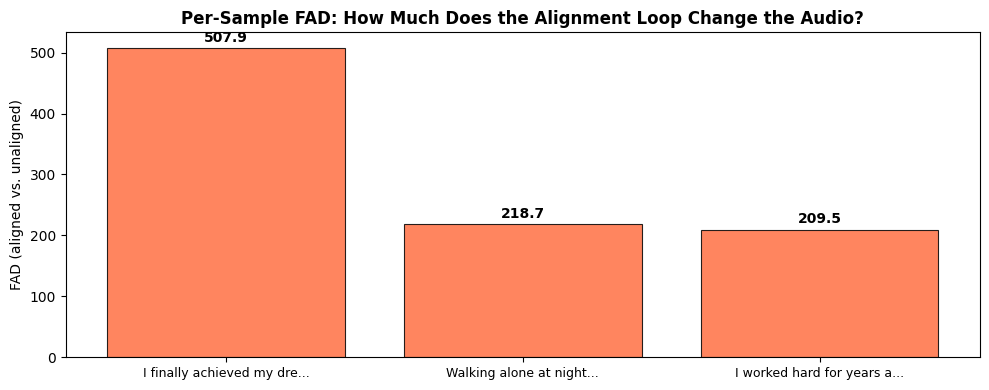

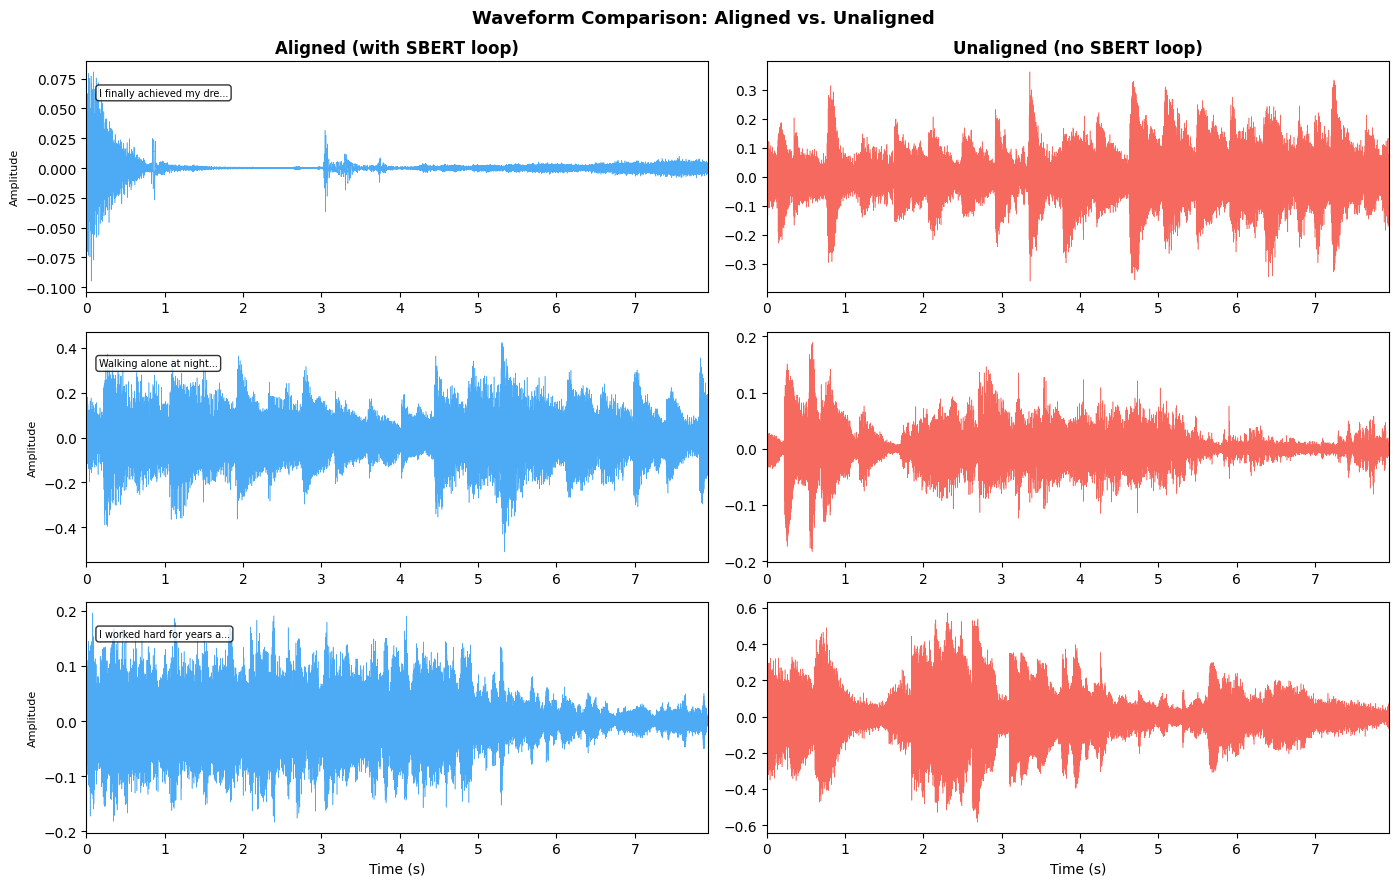

In [10]:
# --- FAD Visualizations ---

fig = plt.figure(figsize=(16, 12))

# --- 1. Mel Spectrogram Comparison (aligned vs unaligned for each sample) ---
for i in range(len(FAD_EVAL_TEXTS)):
    # Aligned mel spectrogram
    ax = fig.add_subplot(len(FAD_EVAL_TEXTS) + 1, 2, 2 * i + 1)
    ax.imshow(aligned_features[i].T, aspect="auto", origin="lower", cmap="magma", interpolation="nearest")
    ax.set_ylabel("Mel Bin")
    if i == 0:
        ax.set_title("With Alignment Loop", fontsize=11, fontweight="bold")
    short = FAD_EVAL_TEXTS[i].split(",")[0][:30] + "..."
    ax.set_ylabel(f"{short}\nMel Bin", fontsize=8)
    if i == len(FAD_EVAL_TEXTS) - 1:
        ax.set_xlabel("Time Frame")

    # Unaligned mel spectrogram
    ax = fig.add_subplot(len(FAD_EVAL_TEXTS) + 1, 2, 2 * i + 2)
    ax.imshow(unaligned_features[i].T, aspect="auto", origin="lower", cmap="magma", interpolation="nearest")
    if i == 0:
        ax.set_title("Without Alignment Loop", fontsize=11, fontweight="bold")
    ax.set_yticks([])
    if i == len(FAD_EVAL_TEXTS) - 1:
        ax.set_xlabel("Time Frame")

# --- 2. FAD Bar Chart (bottom row, spans both columns) ---
ax = fig.add_subplot(len(FAD_EVAL_TEXTS) + 1, 1, len(FAD_EVAL_TEXTS) + 1)

fad_labels = ["Aligned\n(internal)", "Unaligned\n(internal)", "Cross-group"]
fad_values = [fad_aligned_consistency, fad_unaligned_consistency, fad_cross]
bar_colors = ["#4CAF50", "#F44336", "#9C27B0"]
bars = ax.bar(fad_labels, fad_values, color=bar_colors, alpha=0.85, width=0.5, edgecolor="black", linewidth=0.8)

# Add value labels on bars
for bar, val in zip(bars, fad_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(fad_values) * 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontweight="bold", fontsize=11)

ax.set_ylabel("FAD Score (lower = more similar)")
ax.set_title("Frechet Audio Distance: Ablation Results", fontsize=12, fontweight="bold")

plt.suptitle("FAD Ablation: Aligned vs. Unaligned Audio Generation", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# --- 3. Per-Sample FAD Comparison ---
fig, ax = plt.subplots(figsize=(10, 4))
sample_labels = [t.split(",")[0][:25] + "..." for t in FAD_EVAL_TEXTS]
x_pos = np.arange(len(FAD_EVAL_TEXTS))

ax.bar(x_pos, per_sample_fad, color="#FF7043", alpha=0.85, edgecolor="black", linewidth=0.8)
for j, val in enumerate(per_sample_fad):
    ax.text(j, val + max(per_sample_fad) * 0.02, f"{val:.1f}", ha="center", fontweight="bold", fontsize=10)

ax.set_xticks(x_pos)
ax.set_xticklabels(sample_labels, fontsize=9)
ax.set_ylabel("FAD (aligned vs. unaligned)")
ax.set_title("Per-Sample FAD: How Much Does the Alignment Loop Change the Audio?", fontweight="bold")
plt.tight_layout()
plt.show()

# --- 4. Waveform Comparison ---
fig, axes = plt.subplots(len(FAD_EVAL_TEXTS), 2, figsize=(14, 3 * len(FAD_EVAL_TEXTS)), sharex=False)
for i in range(len(FAD_EVAL_TEXTS)):
    # Aligned waveform
    t_a = np.linspace(0, len(aligned_audios[i]) / aligned_srs[i], len(aligned_audios[i]))
    axes[i, 0].plot(t_a, aligned_audios[i], color="#2196F3", linewidth=0.4, alpha=0.8)
    axes[i, 0].set_ylabel("Amplitude", fontsize=8)
    axes[i, 0].set_xlim(0, t_a[-1])
    if i == 0:
        axes[i, 0].set_title("Aligned (with SBERT loop)", fontweight="bold")
    short = FAD_EVAL_TEXTS[i].split(",")[0][:25] + "..."
    axes[i, 0].text(0.02, 0.85, short, transform=axes[i, 0].transAxes, fontsize=7,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    # Unaligned waveform
    t_u = np.linspace(0, len(unaligned_audios[i]) / unaligned_srs[i], len(unaligned_audios[i]))
    axes[i, 1].plot(t_u, unaligned_audios[i], color="#F44336", linewidth=0.4, alpha=0.8)
    axes[i, 1].set_xlim(0, t_u[-1])
    if i == 0:
        axes[i, 1].set_title("Unaligned (no SBERT loop)", fontweight="bold")

    if i == len(FAD_EVAL_TEXTS) - 1:
        axes[i, 0].set_xlabel("Time (s)")
        axes[i, 1].set_xlabel("Time (s)")

plt.suptitle("Waveform Comparison: Aligned vs. Unaligned", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
def generate_emotion_music(text_input: str, duration: int = 10, temperature: float = 1.0, seed: Optional[int] = None):
    """End-to-end pipeline: text -> emotion -> LLM prompt -> alignment check -> audio.

    Returns a dict with audio data, emotion analysis, music prompt,
    alignment score, and generation metadata.
    """
    if not isinstance(text_input, str) or not text_input.strip():
        raise ValueError("Please provide non-empty text.")
    if len(text_input) > 2000:
        raise ValueError("Text is too long. Please keep it under 2000 characters.")

    duration = int(max(5, min(30, duration)))
    temperature = float(max(0.7, min(1.3, temperature)))

    if seed is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    # Stage 1: Emotion detection (RoBERTa)
    print("[Stage 1] Emotion detection...")
    analysis = analyze_emotions(text_input, top_k=5)
    primary = analysis["primary"]
    print(f"  Detected: {analysis['emotional_blend']}")
    print(f"  Primary: {primary['label'].upper()} ({primary['score']:.1%})")
    print(f"  Confidence: {analysis['confidence']} (entropy={analysis['entropy']:.3f})")

    # Stage 2+3: LLM prompt generation + SBERT alignment loop
    print("[Stage 2+3] Generating music prompt with alignment check...")
    music_prompt, alignment_score, attempts = generate_aligned_prompt(
        text_input, analysis["emotions"]
    )
    print(f"  Final prompt: '{music_prompt}'")
    print(f"  Alignment: {alignment_score:.3f} | Attempts: {attempts}")

    # Stage 4: Audio synthesis (MusicGen)
    print(f"[Stage 4] Generating {duration}s of audio...")
    sampling_rate, audio_data = generate_audio_from_prompt(
        music_prompt=music_prompt,
        duration=duration,
        temperature=temperature,
    )
    print("  Audio generated.")

    return {
        "audio": (sampling_rate, audio_data),
        "emotions": analysis["emotions"],
        "primary": analysis["primary"],
        "emotional_blend": analysis["emotional_blend"],
        "entropy": analysis["entropy"],
        "confidence": analysis["confidence"],
        "music_prompt": music_prompt,
        "alignment_score": alignment_score,
        "generation_attempts": attempts,
    }

## Step 7 — End-to-End Pipeline

Chains all 4 models sequentially:
1. **RoBERTa** detects emotions + computes entropy (confidence).
2. **Flan-T5** generates a music prompt from emotions + original text.
3. **SBERT** checks alignment; triggers regeneration if below threshold.
4. **MusicGen** synthesizes audio from the final prompt.

Returns structured metadata for full pipeline transparency.

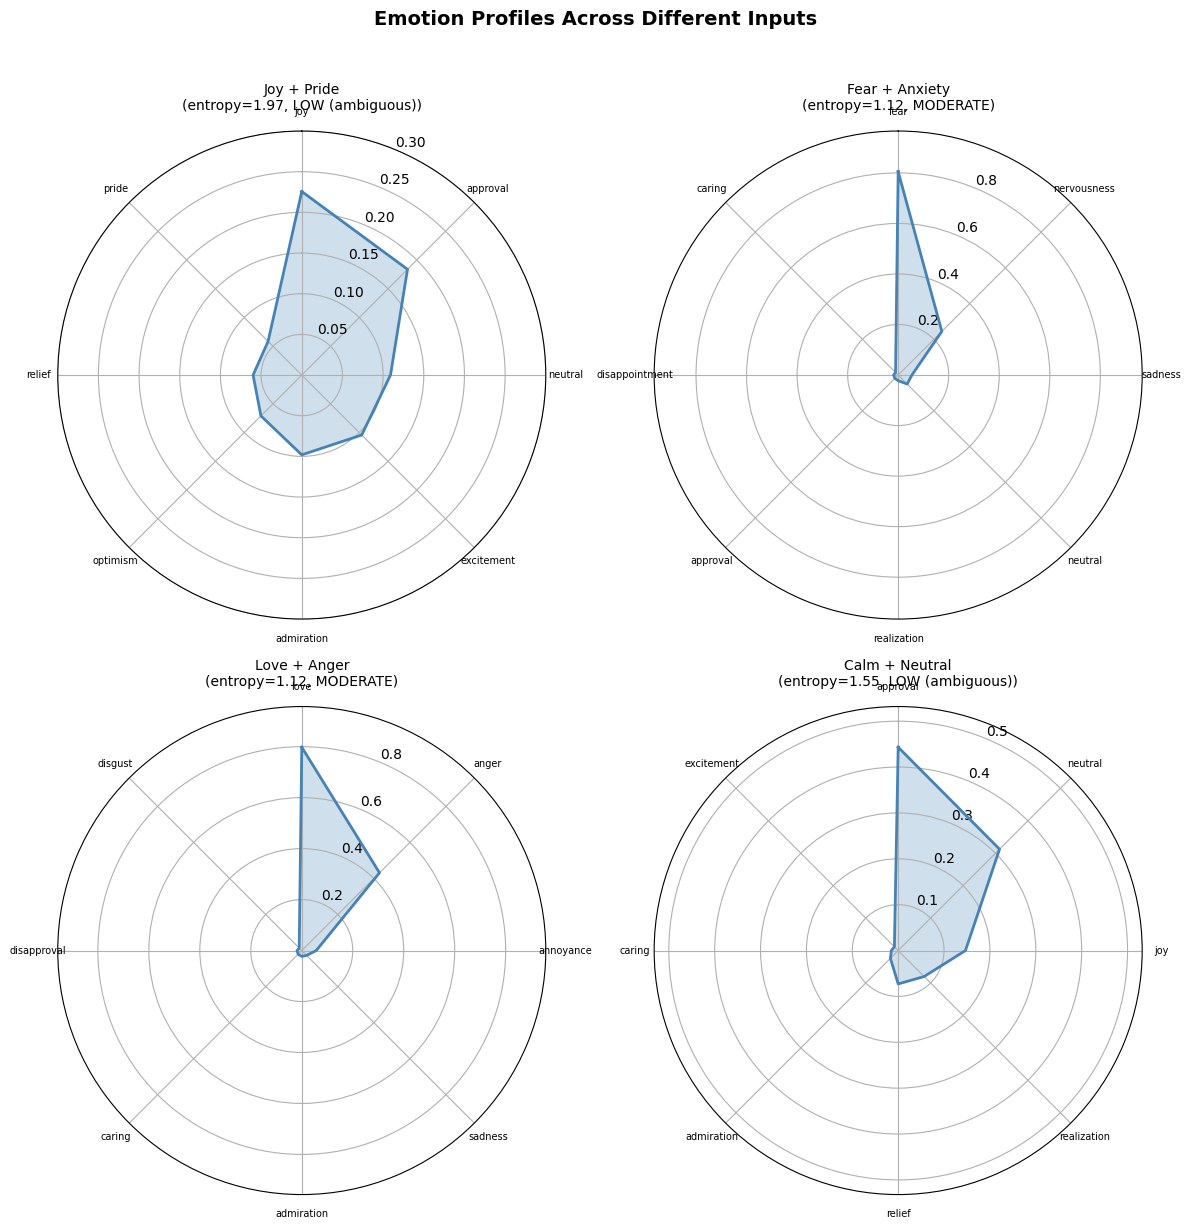

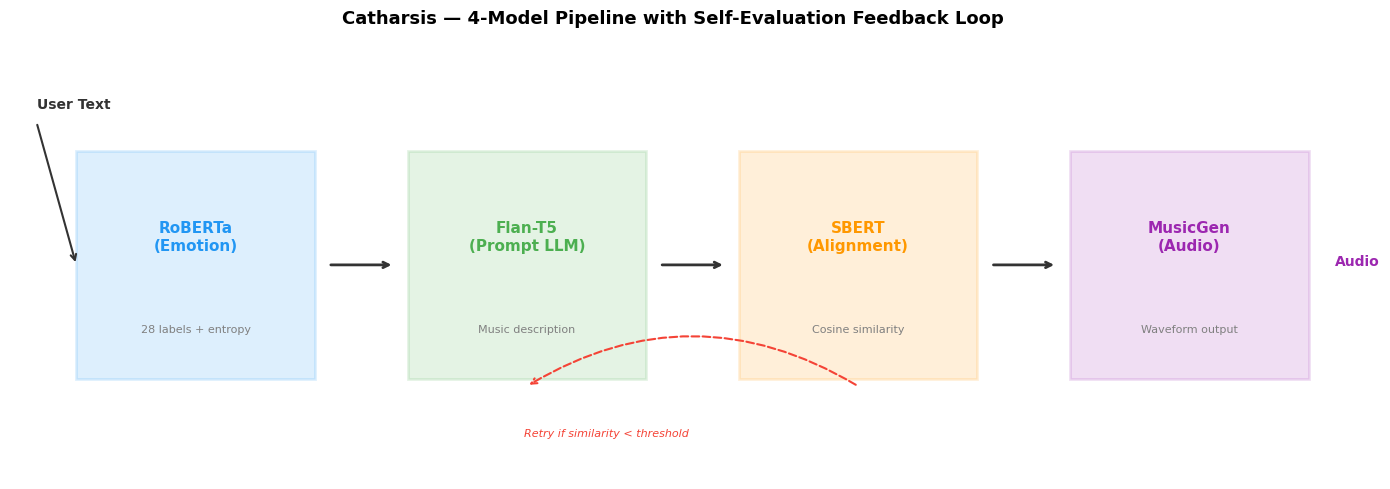

In [12]:
# --- Multi-Example Emotion Radar Comparison ---
# Show radar charts for 4 contrasting examples side by side

comparison_texts = {
    "Joy + Pride": "I worked hard for years and today I finally succeeded!",
    "Fear + Anxiety": "Walking alone at night, every shadow makes my heart race with dread.",
    "Love + Anger": "I love you but I'm so angry at what you did.",
    "Calm + Neutral": "Today felt calm and ordinary, not too high and not too low.",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 12), subplot_kw=dict(polar=True))

for idx, (title, text) in enumerate(comparison_texts.items()):
    ax = axes[idx // 2][idx % 2]
    analysis = analyze_emotions(text, top_k=8)
    emotions = analysis["emotions"]

    labels = [e["label"] for e in emotions]
    scores = [e["score"] for e in emotions]
    N = len(labels)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    scores_plot = scores + scores[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=7)
    ax.set_ylim(0, max(max(scores) * 1.2, 0.3))

    ax.plot(angles, scores_plot, linewidth=2, color="steelblue")
    ax.fill(angles, scores_plot, alpha=0.25, color="steelblue")
    ax.set_title(f"{title}\n(entropy={analysis['entropy']:.2f}, {analysis['confidence']})",
                 size=10, pad=15)

plt.suptitle("Emotion Profiles Across Different Inputs", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# --- Pipeline Architecture Summary ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.axis("off")

# Draw the 4 pipeline stages as boxes with arrows
stages = [
    {"x": 0.5, "label": "RoBERTa\n(Emotion)", "color": "#2196F3", "detail": "28 labels + entropy"},
    {"x": 3.0, "label": "Flan-T5\n(Prompt LLM)", "color": "#4CAF50", "detail": "Music description"},
    {"x": 5.5, "label": "SBERT\n(Alignment)", "color": "#FF9800", "detail": "Cosine similarity"},
    {"x": 8.0, "label": "MusicGen\n(Audio)", "color": "#9C27B0", "detail": "Waveform output"},
]

box_w, box_h = 1.8, 1.6
for s in stages:
    rect = plt.Rectangle((s["x"], 0.7), box_w, box_h, linewidth=2,
                          edgecolor=s["color"], facecolor=s["color"], alpha=0.15, zorder=2)
    ax.add_patch(rect)
    ax.text(s["x"] + box_w / 2, 1.7, s["label"], ha="center", va="center",
            fontsize=11, fontweight="bold", color=s["color"], zorder=3)
    ax.text(s["x"] + box_w / 2, 1.05, s["detail"], ha="center", va="center",
            fontsize=8, color="gray", zorder=3)

# Arrows between stages
for i in range(len(stages) - 1):
    ax.annotate("", xy=(stages[i + 1]["x"] - 0.1, 1.5),
                xytext=(stages[i]["x"] + box_w + 0.1, 1.5),
                arrowprops=dict(arrowstyle="->", lw=2, color="#333"))

# Feedback loop arrow from SBERT back to Flan-T5
ax.annotate("", xy=(stages[1]["x"] + box_w / 2, 0.65),
            xytext=(stages[2]["x"] + box_w / 2, 0.65),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#F44336", linestyle="--",
                            connectionstyle="arc3,rad=0.3"))
ax.text(4.5, 0.3, "Retry if similarity < threshold", ha="center", fontsize=8,
        color="#F44336", fontstyle="italic")

# Title and input/output labels
ax.text(0.2, 2.6, "User Text", fontsize=10, fontweight="bold", color="#333")
ax.annotate("", xy=(stages[0]["x"], 1.5), xytext=(0.2, 2.5),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#333"))

ax.text(stages[-1]["x"] + box_w + 0.2, 1.5, "Audio", fontsize=10, fontweight="bold", color="#9C27B0")

ax.set_title("Catharsis — 4-Model Pipeline with Self-Evaluation Feedback Loop",
             fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

In [13]:
def gradio_interface(text, duration, temperature, seed):
    """Gradio wrapper — runs full pipeline and formats output for UI."""
    try:
        if not text or not str(text).strip():
            raise ValueError("Text input is empty.")

        result = generate_emotion_music(
            text_input=text,
            duration=duration,
            temperature=temperature,
            seed=int(seed) if seed is not None else None,
        )

        # Format pipeline transparency output
        emotions_str = ", ".join(
            [f"{e['label']} ({e['score']:.1%})" for e in result["emotions"]]
        )

        alignment_indicator = ""
        if result["alignment_score"] >= 0.3:
            alignment_indicator = "Strong"
        elif result["alignment_score"] >= 0.15:
            alignment_indicator = "Acceptable"
        else:
            alignment_indicator = "Weak"

        output_md = (
            f"### Stage 1: Emotion Detection (RoBERTa)\n"
            f"**Emotional blend:** {result['emotional_blend']}\n\n"
            f"**All detected:** {emotions_str}\n\n"
            f"**Confidence:** {result['confidence']} (entropy = {result['entropy']:.3f})\n\n"
            f"---\n"
            f"### Stage 2: Music Prompt (Flan-T5-Base)\n"
            f"**Generated prompt:** {result['music_prompt']}\n\n"
            f"---\n"
            f"### Stage 3: Alignment Check (SBERT)\n"
            f"**Cosine similarity:** {result['alignment_score']:.3f} ({alignment_indicator})\n\n"
            f"**Generation attempts:** {result['generation_attempts']}"
            f"{' (feedback loop triggered!)' if result['generation_attempts'] > 1 else ''}\n\n"
            f"---\n"
            f"### Stage 4: Audio Synthesis (MusicGen)\n"
            f"Audio generated below."
        )

        return result["audio"], output_md
    except Exception as e:
        return None, f"Generation failed: {str(e)}"


examples = [
    ["I finally achieved my dream, but I miss the journey getting here.", 12, 1.0, 42],
    ["I'm excited but terrified about my first day at the new job tomorrow!", 10, 1.0, 42],
    ["I love you but I'm so angry at what you did.", 10, 1.1, 123],
    ["This surprise party is amazing! I had no idea you all cared so much.", 10, 1.0, 7],
    ["Walking alone at night, every shadow makes my heart race with dread.", 15, 1.2, 99],
    ["Today felt calm and ordinary, not too high and not too low.", 8, 0.9, 42],
    ["I worked hard for years and today I feel proud, relieved, and grateful.", 10, 1.0, 2026],
]

demo = gr.Interface(
    fn=gradio_interface,
    inputs=[
        gr.Textbox(
            label="How are you feeling?",
            placeholder="Example: I'm happy but nostalgic about graduating college...",
            lines=5,
        ),
        gr.Slider(5, 30, 10, step=1, label="Duration (seconds)"),
        gr.Slider(0.7, 1.3, 1.0, step=0.1, label="Creativity (temperature)"),
        gr.Number(value=42, label="Seed (for reproducibility)", precision=0),
    ],
    outputs=[
        gr.Audio(label="Your Soundtrack", type="numpy"),
        gr.Markdown(label="Pipeline Transparency"),
    ],
    title="Catharsis — Your Feelings Deserve a Soundtrack",
    description=(
        "**A 4-model AI pipeline with a self-evaluation feedback loop.**\n\n"
        "1. **RoBERTa** detects 28 emotions from your text\n"
        "2. **Flan-T5-Base** generates a music description from your emotions\n"
        "3. **SBERT** checks if the description aligns with your text (regenerates if not)\n"
        "4. **MusicGen** synthesizes your personalized soundtrack"
    ),
    examples=examples,
    cache_examples=False,
)

in_colab = "google.colab" in sys.modules
demo.launch(share=in_colab)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bde00e70b442f5cdd4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Step 8 — Interactive Demo (Gradio)

The Gradio interface exposes the full pipeline with **pipeline transparency** — every stage's output is displayed:
- Stage 1: Detected emotions + confidence level
- Stage 2: The LLM-generated music prompt
- Stage 3: Alignment score + whether the feedback loop was triggered
- Stage 4: The generated audio

This transparency is critical for both debugging and demonstrating the AI pipeline to non-technical stakeholders.

## Limitations and Ethics

### Known Limitations

- **Emotion classifier granularity**: GoEmotions was trained on Reddit comments and maps to 28 fine-grained labels. Compound emotions like "bittersweet pride" or "nostalgic relief" are decomposed into constituent parts (e.g., `admiration` + `sadness`) that may not match intuitive human labeling. The `emotional_blend` field partially addresses this by presenting multiple significant emotions together rather than forcing a single primary label.

- **Flan-T5-Base quality ceiling**: At 250M parameters, Flan-T5-Base is the minimum viable size for coherent instruction-following. It generates structured music descriptions reliably but lacks the creative depth of larger models (flan-t5-large at 780M or flan-t5-xl at 3B). Upgrading would improve prompt richness at the cost of GPU memory and latency.

- **SBERT alignment is semantic, not emotional**: Cosine similarity measures topical/semantic overlap, not emotional alignment. A prompt describing "dark minor-key piano" may score low similarity to "I'm sad" even though the emotional mapping is correct. This is a fundamental limitation of using a general-purpose sentence encoder for cross-domain alignment. A fine-tuned emotion-music cross-encoder would be more accurate.

- **Feedback loop tradeoffs**: The alignment threshold (0.30) and retry limit (3 attempts) are hyperparameters that trade quality for latency. Higher thresholds may cause the loop to exhaust retries on texts where semantic similarity is inherently low (e.g., abstract poetry). Lower thresholds let poor prompts through.

- **FAD metric scope**: Our FAD ablation uses mel-spectrogram features rather than a learned audio embedding model (like VGGish or CLAP). This captures timbral/spectral differences but is less sensitive to high-level musical quality. A production evaluation would use VGGish-based FAD with a large reference corpus.

- **Evaluation scale**: While 21 examples is sufficient to demonstrate the pipeline and identify patterns, it is not large enough for statistically robust conclusions. A full evaluation would use 100+ diverse examples with human-rated alignment scores.

### Ethical Considerations

- **Not a diagnostic tool**: This is a creative-assist system. It should not be used for mental health assessment or emotional diagnosis.
- **Cultural bias**: The emotion classifier inherits biases from its English Reddit training data — it may misclassify emotions expressed in non-Western communication styles.
- **Privacy**: Avoid uploading sensitive personal text when sharing public demos.

### Future Work

- Upgrade to flan-t5-large or flan-t5-xl for richer music descriptions.
- Fine-tune a cross-encoder on emotion-music pairs for more accurate alignment scoring.
- Add VGGish/CLAP-based FAD for industry-standard audio quality evaluation.
- Expand evaluation to 100+ examples with crowdsourced human ratings.
- Explore conditioning MusicGen directly on emotion embeddings (bypassing text prompts entirely).